# PyTorch basics

В этой тетрадке мы познакомимся с общими принципами построения нейронных сетей.

**Цели тетрадки**

1. Знакомство с базовыми слоями PyTorch
1. Практика в построении и обучении сетей

**(повтор) Материалы по pytorch:**

* [PyTorch docs](https://pytorch.org/docs/stable/index.html)
* [Классная статья про pytorch internal](http://blog.ezyang.com/2019/05/pytorch-internals/)

## Prerequirements

```
pip install torch torchvision numpy matplotlib
```

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt

## Hello MNIST

Прежде чем собирать сеть, давайте определим инстансы класса `Dataset`, которые будут возвращать примеры из тренировочной и валидационной выборок.  
С помощью ячейки ниже, мы скачаем датасет [MNIST](http://yann.lecun.com/exdb/mnist/) в текущую директорию и сможем получать примеры из соответствующих объектов.

In [2]:
transform_to_tensor = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = MNIST(root='./', train=True, download=True, transform=transform_to_tensor)
mnist_val = MNIST(root='./', train=False, download=True, transform=transform_to_tensor)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.21MB/s]


Посмотрим на несколько примеров из тренировочной выборки

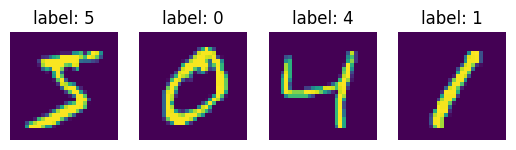

In [3]:
def show_examples(dataset: Dataset, num_examples: int = 4):
    fig, ax = plt.subplots(1, num_examples)

    for i in range(num_examples):
        img, label = dataset[i]
        ax[i].imshow(img[0])
        ax[i].set_title(f'label: {label}')
        ax[i].axis('off')
    plt.show()


show_examples(dataset=mnist_train)

## Задание 1
**(0.5 балла)** Напишите свою версию датасета, который будет читать картинки с диска.  
Подразумевается, что если вы написали свой датасет, то он будет использоваться при обучении вместо дефолтного `MNIST`.  

В ячейках ниже сгенерится датасет в таком формате:
- /MNIST_image_folder
    - /train.csv
    - /train/{class_name}/{image_name}.png
    - /val.csv
    - /val/{class_name}/{image_name}.png

CSV файлы содержат название файла и его лейбл: `image`, `label`.

*Hint 1:* нужно унаследоваться от класса `Dataset` и переопределить методы `__getitem__` и `__len__`.
Первый должен возвращать картинку и ее лейбл, а второй количество примеров в датасете.
(На самом деле второй метод не обязателен для самого датасета, но он необходим для
[семплера](https://pytorch.org/docs/stable/data.html#torch.utils.data.RandomSampler),
который используется даталоадером)
(см. [PyTorch docs](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset),
[PyTorch tutorual](https://pytorch.org/tutorials/recipes/recipes/custom_dataset_transforms_loader.html?highlight=dataset))  
*Hint 2:* для работы с картинками лучше использовать OpenCV: `pip install opencv-python-headless`.
В частности [cv2.imread](https://docs.opencv.org/master/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56).  
*Hint 3:* обратите особое внимание на то, что возвращает функция `cv2.imread` (пример загрузки изображения с помощью cv2 есть в семе)


In [4]:
import pickle
import numpy as np
import os
import cv2
from collections import Counter
from tqdm.auto import tqdm
import pandas as pd

def generate_image_folder_dataset(dataset, target_path, csv_path):

    images_counter = Counter()

    files = []
    labels = []

    for image, label in tqdm(dataset):
        class_folder = target_path + "/" + str(label)
        if not os.path.exists(class_folder):
            os.makedirs(class_folder, exist_ok=True)

        images_counter[label] += 1
        file_name = f"/{images_counter[label]:05}.png"
        full_image_file_name = class_folder + file_name

        files.append(str(label) + file_name)
        labels.append(label)

        image = np.array(image)
        image = (image * 255).astype(np.uint8)
        image = np.transpose(image, [1, 2, 0])
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        # print(image.dtype)
        # print(image.shape)
        cv2.imwrite(full_image_file_name, image)

        # break
    pd.DataFrame({ "image": files, "label": labels }).to_csv(csv_path, index=False)

generate_image_folder_dataset( mnist_train,  "./MNIST_image_folder/train", "MNIST_image_folder/train.csv" )
generate_image_folder_dataset( mnist_val,  "./MNIST_image_folder/val", "MNIST_image_folder/val.csv" )

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Теперь можно написать свой класс датасета для тех файлов, которые мы сгенерили

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import cv2

class DatasetMNIST(Dataset):
    def __init__(self, root='./MNIST_image_folder', train=True, transform=None):
        self.root = root
        self.train = train
        self.transform = transform

        if train:
            self.data_folder = os.path.join(root, "train")
            self.csv_path = os.path.join(root, "train.csv")
        else:
            self.data_folder = os.path.join(root, "val")
            self.csv_path = os.path.join(root, "val.csv")

        self.data = pd.read_csv(self.csv_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        img_relative_path = row["image"]
        label = int(row["label"])

        img_path = os.path.join(self.data_folder, img_relative_path)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "label": label
        }

тест класса датасета

In [16]:
def test_dataset(dataset, test_name=""):

    assert len(dataset) > 0, f"{test_name}: dataset length is greater then zero"

    idateset = iter(dataset)
    item = next(idateset)

    assert isinstance(item, dict), f"{test_name}: dataset returned dict"
    assert "image" in item, f"{test_name}: dataset item dict has image"
    assert "label" in item, f"{test_name}: dataset item dict has label"

    assert item['image'].shape == (1, 28, 28), f"{test_name}: dataset image shape is correct. Got: {item['image'].shape}"

mydataset = DatasetMNIST(train=False, transform=transform_to_tensor)
test_dataset(mydataset, test_name="val")

mydataset = DatasetMNIST(train=True, transform=transform_to_tensor)
test_dataset(mydataset, test_name="train")

## Задание 2
**(0.3 балла)** Напишите класс MLP сети из 3 линейных слоев, которая будет получать на вход
батч картинок размера [BS, C, H, W]

*Hint 1:* метод `.flatten(start_dim=1)` поможет вытянуть картинку в вектор.  
*Hint 2:* выход должен соответствовать количеству лейблов, то есть 10.  
*Hint 3:* пачка линейных слоев подряд не имеет смысла без нелинейностей между ними. Попробуйте разные слои нелинейности (один слой на один эксперимент): `ReLU`, `LeakyReLU`, `Tanh` ... [Другие](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)

In [63]:
# важно! все зависимости, которые используете (если добавляее новые) в этом классе надо явно продублировать в эту ячейку
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomMLP(nn.Module):
    def __init__(self
                 ,num_pixels_per_img: int = 784  # hint: 28*28 == 784
                 ,hidden_dim: int = 256
                 ,activation: str = "relu" #Gecrfq jyf ,eltn gj ltajkne
                 ):
        super().__init__()

        # here you can init layers and stack them with nn.Sequential
        # todo
        # ...
        if activation == "relu":
            act_layer = nn.ReLU()
        elif activation == "leaky_relu":
            act_layer = nn.LeakyReLU()
        elif activation == "tanh":
            act_layer = nn.Tanh()
        elif activation == "rrelu":
            act_layer = nn.RReLU()
        elif activation == "relu6":
            act_layer = nn.ReLU6()
        elif activation == "tanhsh":
            act_layer = nn.Tanhshrink()

        self.model = nn.Sequential(
            nn.Linear(num_pixels_per_img, hidden_dim),
            act_layer,
            nn.Linear(hidden_dim, hidden_dim),
            act_layer,
            nn.Linear(hidden_dim, 10)  # 10 классов MNIST
        )


    def forward(self, x):
        # describe usage of layers here, be careful with input shape
        x = x.flatten(start_dim=1)
        logits = self.model(x)
        return logits

    def compute_all(self, batch):

        # todo
        images = batch["image"]
        labels = batch["label"]

        logits = self.forward(images)
        loss = F.cross_entropy(logits, labels)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()

        return {
            "loss": loss,
            "logits": logits,
            "preds": preds,
            "acc": acc
        }

In [20]:
model = CustomMLP(activation="relu")

In [21]:
model

CustomMLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

## Задание 3
**(0.3 балла)** Напишите класс CNN сети из 3 сверточных слоев.

*Hint 1:* на вход все те же батчи размера [BS, C, H, W]  
*Hint 2:* описание сверточных слоев [PyTorch docs](https://pytorch.org/docs/stable/nn.html#convolution-layers). Нам нужен `Conv2d`

Тут тоже можете поэксперементировать с разными слоями активации.

Чтобы было проще считать размерности для конечного слоя, используйте `kernel_size=3, padding=1` в сверточных слоях

In [25]:
# важно! все зависимости, которые используете (если добавляее новые) в этом классе надо явно продублировать в эту ячейку
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self
                 ,activation: str = "relu"
                 ):

        super().__init__()

        if activation == "relu":
            act_layer = nn.ReLU()
        elif activation == "leaky_relu":
            act_layer = nn.LeakyReLU()
        elif activation == "tanh":
            act_layer = nn.Tanh()
        else:
            raise ValueError("Unsupported activation")

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            act_layer,
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            act_layer,
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            act_layer,
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Linear(128 * 3 * 3, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        logits = self.classifier(x)
        return logits

    def compute_all(self, batch):  # удобно сделать функцию, в которой вычисляется лосс по пришедшему батчу

        images = batch["image"]
        labels = batch["label"]

        logits = self.forward(images)
        loss = F.cross_entropy(logits, labels)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()

        return {
            "loss": loss,
            "logits": logits,
            "preds": preds,
            "acc": acc
        }

## Задание 4
**(0.3 балла)** Напишите класс CNN сети из 3 блоков с добавлением skip-connection блока
(ResNet [paper](https://arxiv.org/abs/1512.03385)).  
**(0.3 балла)** Реализовать residual блок в отдельном классе `ResBlock`.

*Hint 1:* на вход все те же батчи размера [BS, C, H, W]  
*Hint 2:* пример skip-connection:  
<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/04_cnn/static/skip_connection.png" width=400 />

In [31]:

# важно! все зависимости, которые используете (если добавляее новые) в этом классе надо явно продублировать в эту ячейку
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        """
        in_dim --- размерность слоев на входе (используется в nn.Conv2d)
        hidden_dim --- скрытая размерность слоев (используется в nn.Conv2d)
        """

        # размерность на входе и на  выходе этого модуля должна быть одинаковой
        # чтобы было возможно сложить результат работы этого слоя с его входным тензором

        self.block = nn.Sequential(
            nn.Conv2d(in_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, in_dim, kernel_size=3, padding=1),
        )

        self.activation = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.block(x)
        out = out + identity  # skip-connection
        out = self.activation(out)
        return out


class CustomResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # here you can init layers and stack them with nn.Sequential
        self.stem = nn.Conv2d(1, 32, kernel_size=3, padding=1)

        self.layer1 = ResBlock(32, 64)
        self.pool1 = nn.MaxPool2d(2)  # 28-14

        self.layer2 = ResBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)  # 14-7

        self.layer3 = ResBlock(32, 64)
        self.pool3 = nn.MaxPool2d(2)  # 7-3

        self.classifier = nn.Linear(32 * 3 * 3, 10)

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.pool1(x)

        x = self.layer2(x)
        x = self.pool2(x)

        x = self.layer3(x)
        x = self.pool3(x)

        x = x.flatten(start_dim=1)
        logits = self.classifier(x)

        return logits


    def compute_all(self, batch):  # удобно сделать функцию, в которой вычисляется лосс по пришедшему батчу
        images = batch["image"]
        labels = batch["label"]

        logits = self.forward(images)
        loss = F.cross_entropy(logits, labels)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()

        return {
            "loss": loss,
            "logits": logits,
            "preds": preds,
            "acc": acc
        }

## Задание 5
**(0.3 балла)** Инициализируйте и обучите сети из пунктов 1, 2, 3, используя класс `Trainer` из семинара.

В тренерене, возможно, вы захотите писать больше метрик: лосс во время трейна, валидационный лосс, валидационные метрики (можно префиксовать валидационные метрики с помощью "val", чтобы не путались)

Каждая модель должна побить определенные пороги кач-ва (> 0.8 за 3 эпохи)

In [37]:
from torch.utils.tensorboard import SummaryWriter

class Trainer:
    def __init__(self, model, optimizer, train_dataset, val_dataset, batch_size=128):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.model = model.to(self.device)
        self.optimizer = optimizer

        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        self.writer = SummaryWriter()
        self.global_step = 0

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        total_acc = 0

        for batch in self.train_loader:
            batch = {k: v.to(self.device) for k, v in batch.items()}

            self.optimizer.zero_grad()
            outputs = self.model.compute_all(batch)
            loss = outputs["loss"]

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            total_acc += outputs["acc"].item()

            self.writer.add_scalar("train_loss", loss.item(), self.global_step)
            self.writer.add_scalar("train_acc", outputs["acc"].item(), self.global_step)

            self.global_step += 1

        return total_loss / len(self.train_loader), total_acc / len(self.train_loader)

    @torch.no_grad()
    def val_epoch(self, epoch):
        self.model.eval()
        total_loss = 0
        total_acc = 0

        for batch in self.val_loader:
            batch = {k: v.to(self.device) for k, v in batch.items()}
            outputs = self.model.compute_all(batch)

            total_loss += outputs["loss"].item()
            total_acc += outputs["acc"].item()

        avg_loss = total_loss / len(self.val_loader)
        avg_acc = total_acc / len(self.val_loader)

        self.writer.add_scalar("val_loss", avg_loss, epoch)
        self.writer.add_scalar("val_acc", avg_acc, epoch)

        return avg_loss, avg_acc

    def train(self, epochs=3):
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(epoch)
            val_loss, val_acc = self.val_epoch(epoch)

            print(f"Epoch {epoch+1}/{epochs}")
            print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}")
            print(f"val_loss:   {val_loss:.4f} | val_acc:   {val_acc:.4f}")
            print("-" * 40)

        self.writer.close()

#### CustomMLP

In [73]:
model = CustomMLP(activation='tanh')
opt = optim.SGD(model.parameters(), lr=3e-2) # я чуть (в 10 раз...) повысил лр, иначе качество не выбивалось (экспериментов было немало)

mnist_train = DatasetMNIST(train=True, transform=transform_to_tensor)
mnist_val = DatasetMNIST(train=False, transform=transform_to_tensor)

trainer = Trainer(model, opt, mnist_train, mnist_val, batch_size=128)

In [75]:
trainer.train(3)
torch.save(model.state_dict(), "custom_mlp.pt") # важно сохранить веса обученой модели!

Epoch 1/3
train_loss: 0.2878 | train_acc: 0.9174
val_loss:   0.2709 | val_acc:   0.9220
----------------------------------------
Epoch 2/3
train_loss: 0.2744 | train_acc: 0.9212
val_loss:   0.2596 | val_acc:   0.9252
----------------------------------------
Epoch 3/3
train_loss: 0.2622 | train_acc: 0.9246
val_loss:   0.2496 | val_acc:   0.9280
----------------------------------------


#### CustomCNN

In [48]:
model = CustomCNN(activation='leaky_relu')
opt = optim.SGD(model.parameters(), lr=3e-3)

mnist_train = DatasetMNIST(train=True, transform=transform_to_tensor)
mnist_val = DatasetMNIST(train=False, transform=transform_to_tensor)

trainer = Trainer(model, opt, mnist_train, mnist_val, batch_size=128)

In [49]:
trainer.train(3)
torch.save(model.state_dict(), "custom_cnn.pt")  # важно сохранить веса обученой модели!

Epoch 1/3
train_loss: 2.2728 | train_acc: 0.2192
val_loss:   2.2274 | val_acc:   0.3062
----------------------------------------
Epoch 2/3
train_loss: 2.0389 | train_acc: 0.5979
val_loss:   1.5776 | val_acc:   0.7227
----------------------------------------
Epoch 3/3
train_loss: 0.9420 | train_acc: 0.7766
val_loss:   0.5789 | val_acc:   0.8400
----------------------------------------


#### CustomResNet

In [42]:
model = CustomResNet()
opt = optim.SGD(model.parameters(), lr=3e-3)

mnist_train = DatasetMNIST(train=True, transform=transform_to_tensor)
mnist_val = DatasetMNIST(train=False, transform=transform_to_tensor)

trainer = Trainer(model, opt, mnist_train, mnist_val, batch_size=128)

In [43]:
trainer.train(3)
torch.save(model.state_dict(), "custom_resnet.pt") # важно сохранить веса обученой модели!

Epoch 1/3
train_loss: 2.1310 | train_acc: 0.3470
val_loss:   1.7330 | val_acc:   0.5584
----------------------------------------
Epoch 2/3
train_loss: 0.8887 | train_acc: 0.7446
val_loss:   0.3667 | val_acc:   0.8968
----------------------------------------
Epoch 3/3
train_loss: 0.2967 | train_acc: 0.9122
val_loss:   0.1988 | val_acc:   0.9439
----------------------------------------


### Тест


In [77]:
import pytest
import torch
import torch.nn as nn

import sys

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

transform_to_tensor = transforms.Compose([
    transforms.ToTensor()
])

mnist_val = MNIST(root='./', train=False, download=True, transform=transform_to_tensor)

def _test_model(model, target_accuracy, flatten=True):
    print(model)

    dataloader = DataLoader(mnist_val, batch_size=128)

    all_logits = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:
            if flatten:
                images = images.flatten(1)
            logits = model(images)
            all_logits.append(logits)
            all_labels.append(labels)

        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)

        print(all_logits.shape, all_labels.shape)

        accuracy = (all_logits.argmax(axis=1) == all_labels).float().mean().cpu().numpy()
        print("accuracy", accuracy)

        assert accuracy > target_accuracy

def test_model_mlp():

    cmlp = CustomMLP()
    cmlp.load_state_dict( torch.load("custom_mlp.pt") )
    cmlp.eval()

    _test_model(cmlp, 0.8, flatten=True)

def test_model_cnn():

    ccnn = CustomCNN()
    ccnn.load_state_dict( torch.load("custom_cnn.pt") )
    ccnn.eval()

    _test_model(ccnn, 0.8, flatten=False)


def test_model_resnet():

    cresnet = CustomResNet()
    cresnet.load_state_dict( torch.load("custom_resnet.pt") )
    cresnet.eval()

    _test_model(cresnet, 0.8, flatten=False)


test_model_mlp()
test_model_cnn()
test_model_resnet()

CustomMLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
torch.Size([10000, 10]) torch.Size([10000])
accuracy 0.8935
CustomCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=1152, out_features=10, bias=True)
)
torch.Size([10000, 10]) torch.Size([10000])
ac

#### Не забываем смотреть графички в wandb / tensorboard

In [52]:
test_model_cnn()


CustomCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=1152, out_features=10, bias=True)
)
torch.Size([10000, 10]) torch.Size([10000])
accuracy 0.8407


In [47]:
test_model_resnet()

CustomResNet(
  (stem): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (layer1): ResBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (activation): ReLU()
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (layer2): ResBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (activation): ReLU()
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (layer3): ResBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (a